# ADAMIXTURE 1000 Genomes Tutorial

This notebook runs a compact end-to-end ADAMIXTURE workflow on chromosome 22 from the 1000 Genomes Project.

You will run:

1. Unsupervised ADAMIXTURE with population labels and an automatic PNG plot.
2. An unsupervised multi-K sweep with a combined PNG plot.
3. Unsupervised cross-validation across multiple K values.
4. Supervised ADAMIXTURE using known super-population labels for a subset of samples.
5. Standalone plotting with `adamixture-plot`.
6. Projection of held-out samples with `adamixture-project`.

## Before You Start

Run the notebook from any directory. The first code cell installs ADAMIXTURE and the small Python dependencies used by the tutorial into the current notebook kernel. Data and result files are written under `.tmp/adamixture_1000_genomes_tutorial/`.

The workflow uses `snputils` to load chromosome 22 from the 1000 Genomes Phase 3 dataset. It filters and subsets samples and variants, then writes the tutorial datasets in PLINK 2 PGEN format using `PGENWriter`, without requiring a PLINK 2 command.

The default sample and variant limits keep the tutorial quick. Increase them for a larger analysis.


## 1. Install Dependencies


In [2]:
import sys

!{sys.executable} -m pip install -q "adamixture" "pandas>=2.0.0" "ipython>=8.0.0" "snputils==1.0.5"


## 2. Imports


In [3]:
import re
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from snputils import load_dataset, PGENWriter


## 3. Configuration


In [4]:
WORK_DIR = Path.cwd().resolve() / ".tmp" / "adamixture_1000_genomes_tutorial"
DATA_DIR = WORK_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = WORK_DIR / "results"

for directory in [RAW_DIR, PROCESSED_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ALL_PGEN = PROCESSED_DIR / "all_5pop_chr22.pgen"
REFERENCE_PGEN = PROCESSED_DIR / "reference_5pop_chr22.pgen"
TARGET_PGEN = PROCESSED_DIR / "target_5pop_chr22.pgen"

ALL_PVAR = PROCESSED_DIR / "all_5pop_chr22.pvar"
REFERENCE_PVAR = PROCESSED_DIR / "reference_5pop_chr22.pvar"
TARGET_PVAR = PROCESSED_DIR / "target_5pop_chr22.pvar"

ALL_PSAM = PROCESSED_DIR / "all_5pop_chr22.psam"
REFERENCE_PSAM = PROCESSED_DIR / "reference_5pop_chr22.psam"
TARGET_PSAM = PROCESSED_DIR / "target_5pop_chr22.psam"

ALL_POPULATION_LABELS = PROCESSED_DIR / "all_population_labels.txt"
ALL_SUPERPOP_LABELS = PROCESSED_DIR / "all_superpopulation_labels.txt"
ALL_GROUP_LABELS = PROCESSED_DIR / "all_group_labels.txt"

REFERENCE_POPULATION_LABELS = PROCESSED_DIR / "reference_population_labels.txt"
REFERENCE_SUPERPOP_LABELS = PROCESSED_DIR / "reference_superpopulation_labels.txt"
REFERENCE_GROUP_LABELS = PROCESSED_DIR / "reference_group_labels.txt"

TARGET_POPULATION_LABELS = PROCESSED_DIR / "target_population_labels.txt"
TARGET_SUPERPOP_LABELS = PROCESSED_DIR / "target_superpopulation_labels.txt"
TARGET_GROUP_LABELS = PROCESSED_DIR / "target_group_labels.txt"

SUPERVISED_LABELS = PROCESSED_DIR / "supervised_training_labels.txt"

SUPERPOPULATIONS = ["AFR", "EUR", "EAS", "AMR", "SAS"]
REFERENCE_SAMPLES_PER_SUPERPOP = 30
TARGET_SAMPLES_PER_SUPERPOP = 10
MINOR_ALLELE_FREQUENCY = 0.05
MAX_VARIANTS = 10000
RANDOM_SEED = 42

DEVICE = "cpu"
THREADS = 1


## 4. Small Helpers


In [5]:
def display_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(WORK_DIR))
    except ValueError:
        return path.name


def display_command(command):
    shown = []
    for item in command:
        if isinstance(item, Path):
            shown.append(display_path(item))
        else:
            shown.append(str(item))
    return " ".join(shown)


def run_command(command, cwd=WORK_DIR):
    print("$ " + display_command(command))
    completed = subprocess.run(
        list(map(str, command)),
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(completed.stdout)
    completed.check_returncode()
    return completed.stdout


def download_file(url, destination):
    destination = Path(destination)
    if destination.exists():
        print(f"Already downloaded: {destination.name}")
        return
    print(f"Downloading {destination.name}")
    with urllib.request.urlopen(url) as response, destination.open("wb") as output:
        shutil.copyfileobj(response, output)
    print(f"Saved: {destination.name}")


def write_labels(path, values):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("\n".join(map(str, values)) + "\n")


def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))


## 5. Load and Prepare Genotype Data


In [6]:
populations = ["ACB", "CEU", "CDX", "CLM", "BEB"]

print("Loading 1kgp via snputils...")
snpobj = load_dataset(
    "1kgp",
    chromosomes=["22"],
    resource="phase3",
    output_dir=RAW_DIR,
    populations=populations,
    max_variants=150000,
    require_biallelic=True,
    require_complete=True,
    require_polymorphic=True,
    snv_only=True,
)

# Select reference and target samples from population metadata
metadata = snpobj.sample_metadata
metadata = metadata.sort_values(["super_population", "population", "sample"]).reset_index(drop=True)

reference_frames = []
target_frames = []
for superpop in SUPERPOPULATIONS:
    group = metadata[metadata["super_population"] == superpop]
    reference_frames.append(group.head(REFERENCE_SAMPLES_PER_SUPERPOP))
    target_frames.append(group.iloc[REFERENCE_SAMPLES_PER_SUPERPOP:REFERENCE_SAMPLES_PER_SUPERPOP + TARGET_SAMPLES_PER_SUPERPOP])

reference_panel = pd.concat(reference_frames, ignore_index=True)
target_panel = pd.concat(target_frames, ignore_index=True)
all_panel = pd.concat([reference_panel, target_panel], ignore_index=True)

# Subsetting/aligning sample order
snpobj_all = snpobj.filter_samples(samples=all_panel["sample"].tolist(), reorder=True)

# Filter by MAF >= 0.05 on the 200 samples to keep common variants
snpobj_all = snpobj_all.filter_maf(maf=MINOR_ALLELE_FREQUENCY)

# Keep the first 10000 variants
snpobj_all = snpobj_all.filter_variants(indexes=np.arange(MAX_VARIANTS), include=True)

# Filter reference and target cohorts from the finalized variants/samples
snpobj_ref = snpobj_all.filter_samples(samples=reference_panel["sample"].tolist(), reorder=True)
snpobj_target = snpobj_all.filter_samples(samples=target_panel["sample"].tolist(), reorder=True)

# Write labels files
write_labels(REFERENCE_POPULATION_LABELS, snpobj_ref.sample_fid)
write_labels(REFERENCE_SUPERPOP_LABELS, snpobj_ref.sample_metadata["super_population"])
write_labels(REFERENCE_GROUP_LABELS, ["1000G"] * len(reference_panel))

write_labels(TARGET_POPULATION_LABELS, snpobj_target.sample_fid)
write_labels(TARGET_SUPERPOP_LABELS, snpobj_target.sample_metadata["super_population"])
write_labels(TARGET_GROUP_LABELS, ["1000G"] * len(target_panel))

write_labels(ALL_POPULATION_LABELS, snpobj_all.sample_fid)
write_labels(ALL_SUPERPOP_LABELS, snpobj_all.sample_metadata["super_population"])
write_labels(ALL_GROUP_LABELS, ["1000G"] * len(all_panel))

# For supervised training, mask the superpopulation of target samples as "-"
supervised_labels = [
    row["super_population"] if row["sample"] in snpobj_ref.samples else "-"
    for _, row in snpobj_all.sample_metadata.iterrows()
]
write_labels(SUPERVISED_LABELS, supervised_labels)

# Write PGEN filesets
PGENWriter(snpobj_all, PROCESSED_DIR / "all_5pop_chr22").write()
PGENWriter(snpobj_ref, PROCESSED_DIR / "reference_5pop_chr22").write()
PGENWriter(snpobj_target, PROCESSED_DIR / "target_5pop_chr22").write()

print(f"Reference samples: {snpobj_ref.n_samples}")
print(f"Target samples: {snpobj_target.n_samples}")
print(f"All tutorial samples: {snpobj_all.n_samples}")
print(f"Selected variants: {snpobj_all.n_snps}")
print(f"All PGEN: {ALL_PGEN.name}")
print(f"Reference PGEN: {REFERENCE_PGEN.name}")
print(f"Target PGEN: {TARGET_PGEN.name}")


Loading 1kgp via snputils...
Reference samples: 150
Target samples: 50
All tutorial samples: 200
Selected variants: 10000
All PGEN: all_5pop_chr22.pgen
Reference PGEN: reference_5pop_chr22.pgen
Target PGEN: target_5pop_chr22.pgen


## 6. Unsupervised Run with Labels

This run trains one K value and writes a PNG plot using the label files prepared above.


$ adamixture -k 5 --data_path data/processed/all_5pop_chr22.pgen --save_dir results/unsupervised_labeled --name unsupervised_labeled --device cpu --labels data/processed/all_population_labels.txt --labels2 data/processed/all_superpopulation_labels.txt --labels3 data/processed/all_group_labels.txt


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Operating system is Darwin (Mac OS)!
    Using

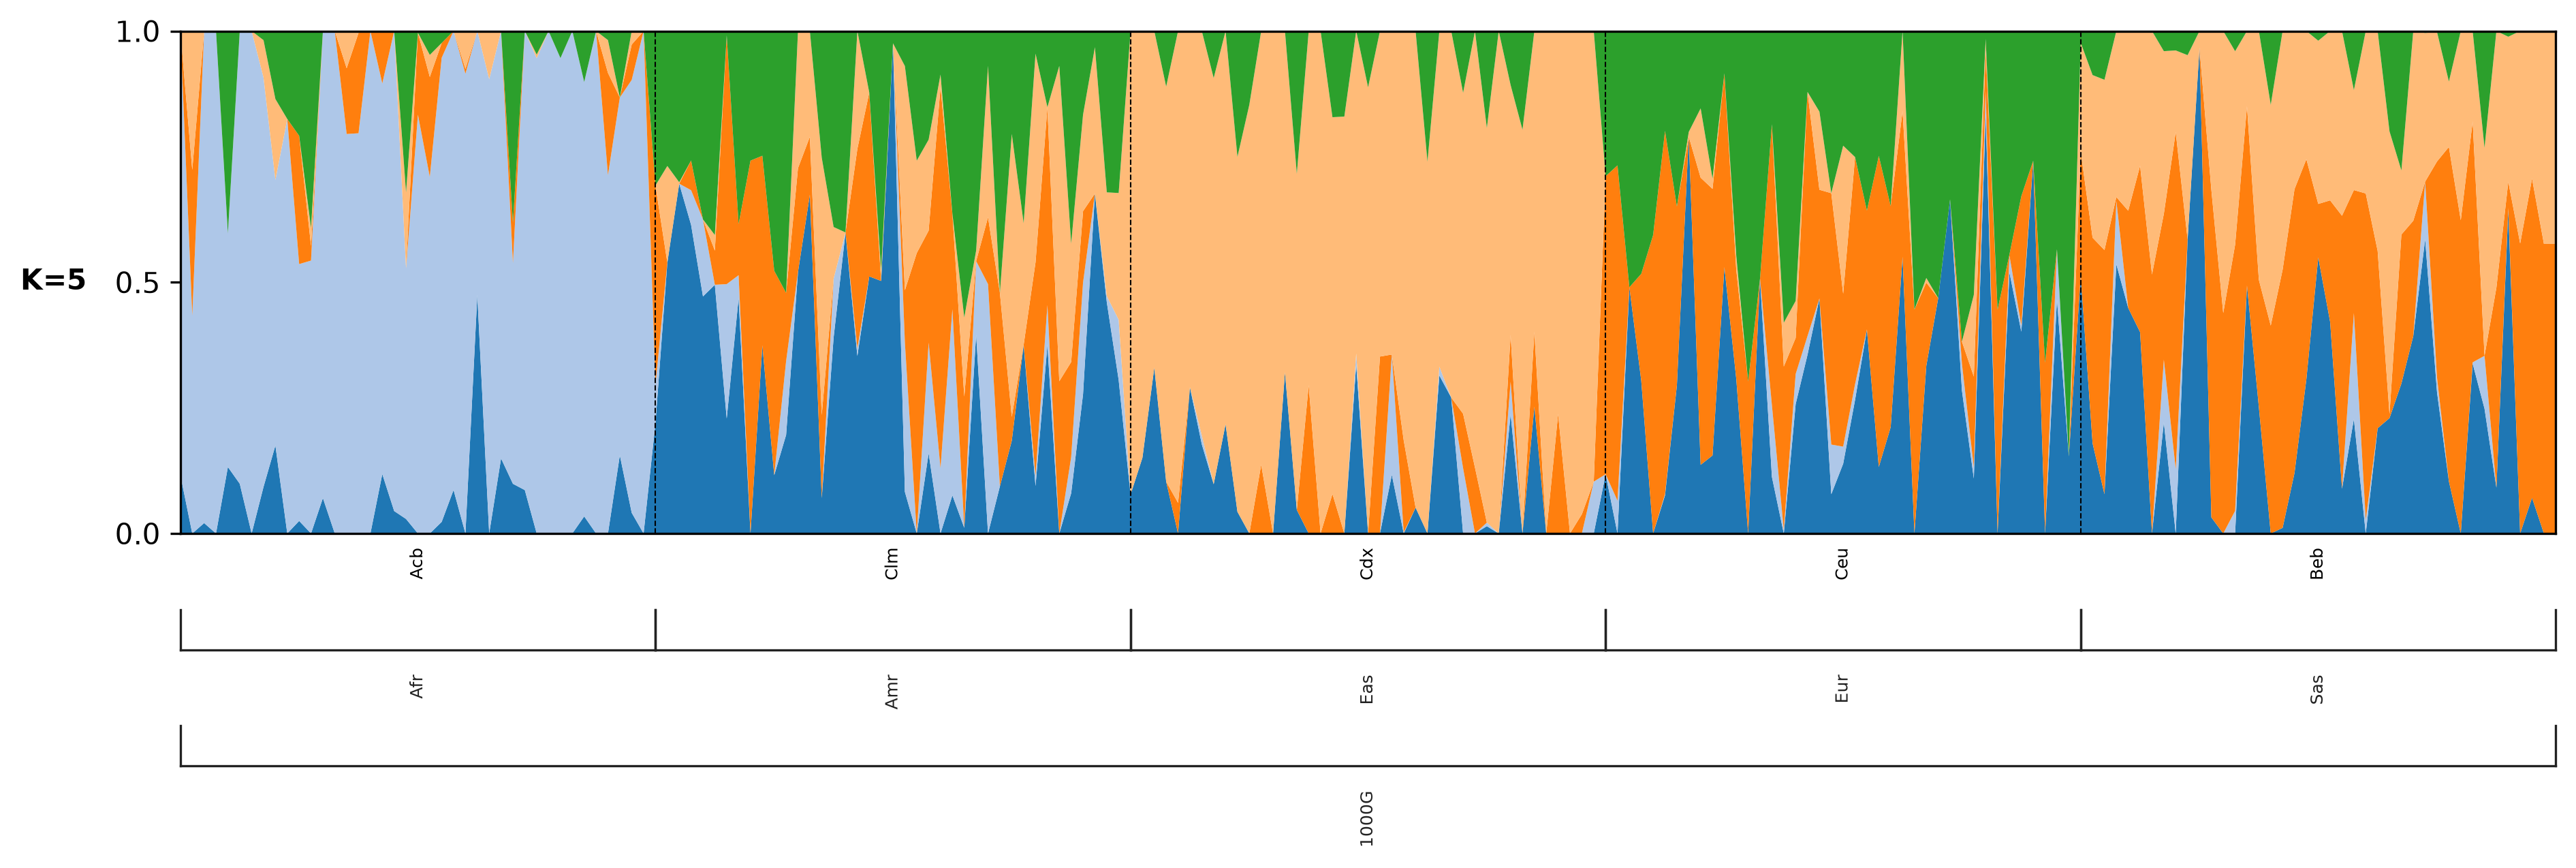

In [7]:
UNSUPERVISED_DIR = RESULTS_DIR / "unsupervised_labeled"
UNSUPERVISED_DIR.mkdir(parents=True, exist_ok=True)

run_command([
    "adamixture",
    "-k", "5",
    "--data_path", ALL_PGEN,
    "--save_dir", UNSUPERVISED_DIR,
    "--name", "unsupervised_labeled",
    "--device", DEVICE,
    "--labels", ALL_POPULATION_LABELS,
    "--labels2", ALL_SUPERPOP_LABELS,
    "--labels3", ALL_GROUP_LABELS,
])

show_png(UNSUPERVISED_DIR / "unsupervised_labeled.5.png")


## 7. Unsupervised Multi-K Sweep


$ adamixture --min_k 3 --max_k 6 --data_path data/processed/all_5pop_chr22.pgen --save_dir results/unsupervised_multi_k --name unsupervised_multi_k --device cpu --labels data/processed/all_population_labels.txt --labels2 data/processed/all_superpopulation_labels.txt --labels3 data/processed/all_group_labels.txt


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Operating system is Darwin (Mac

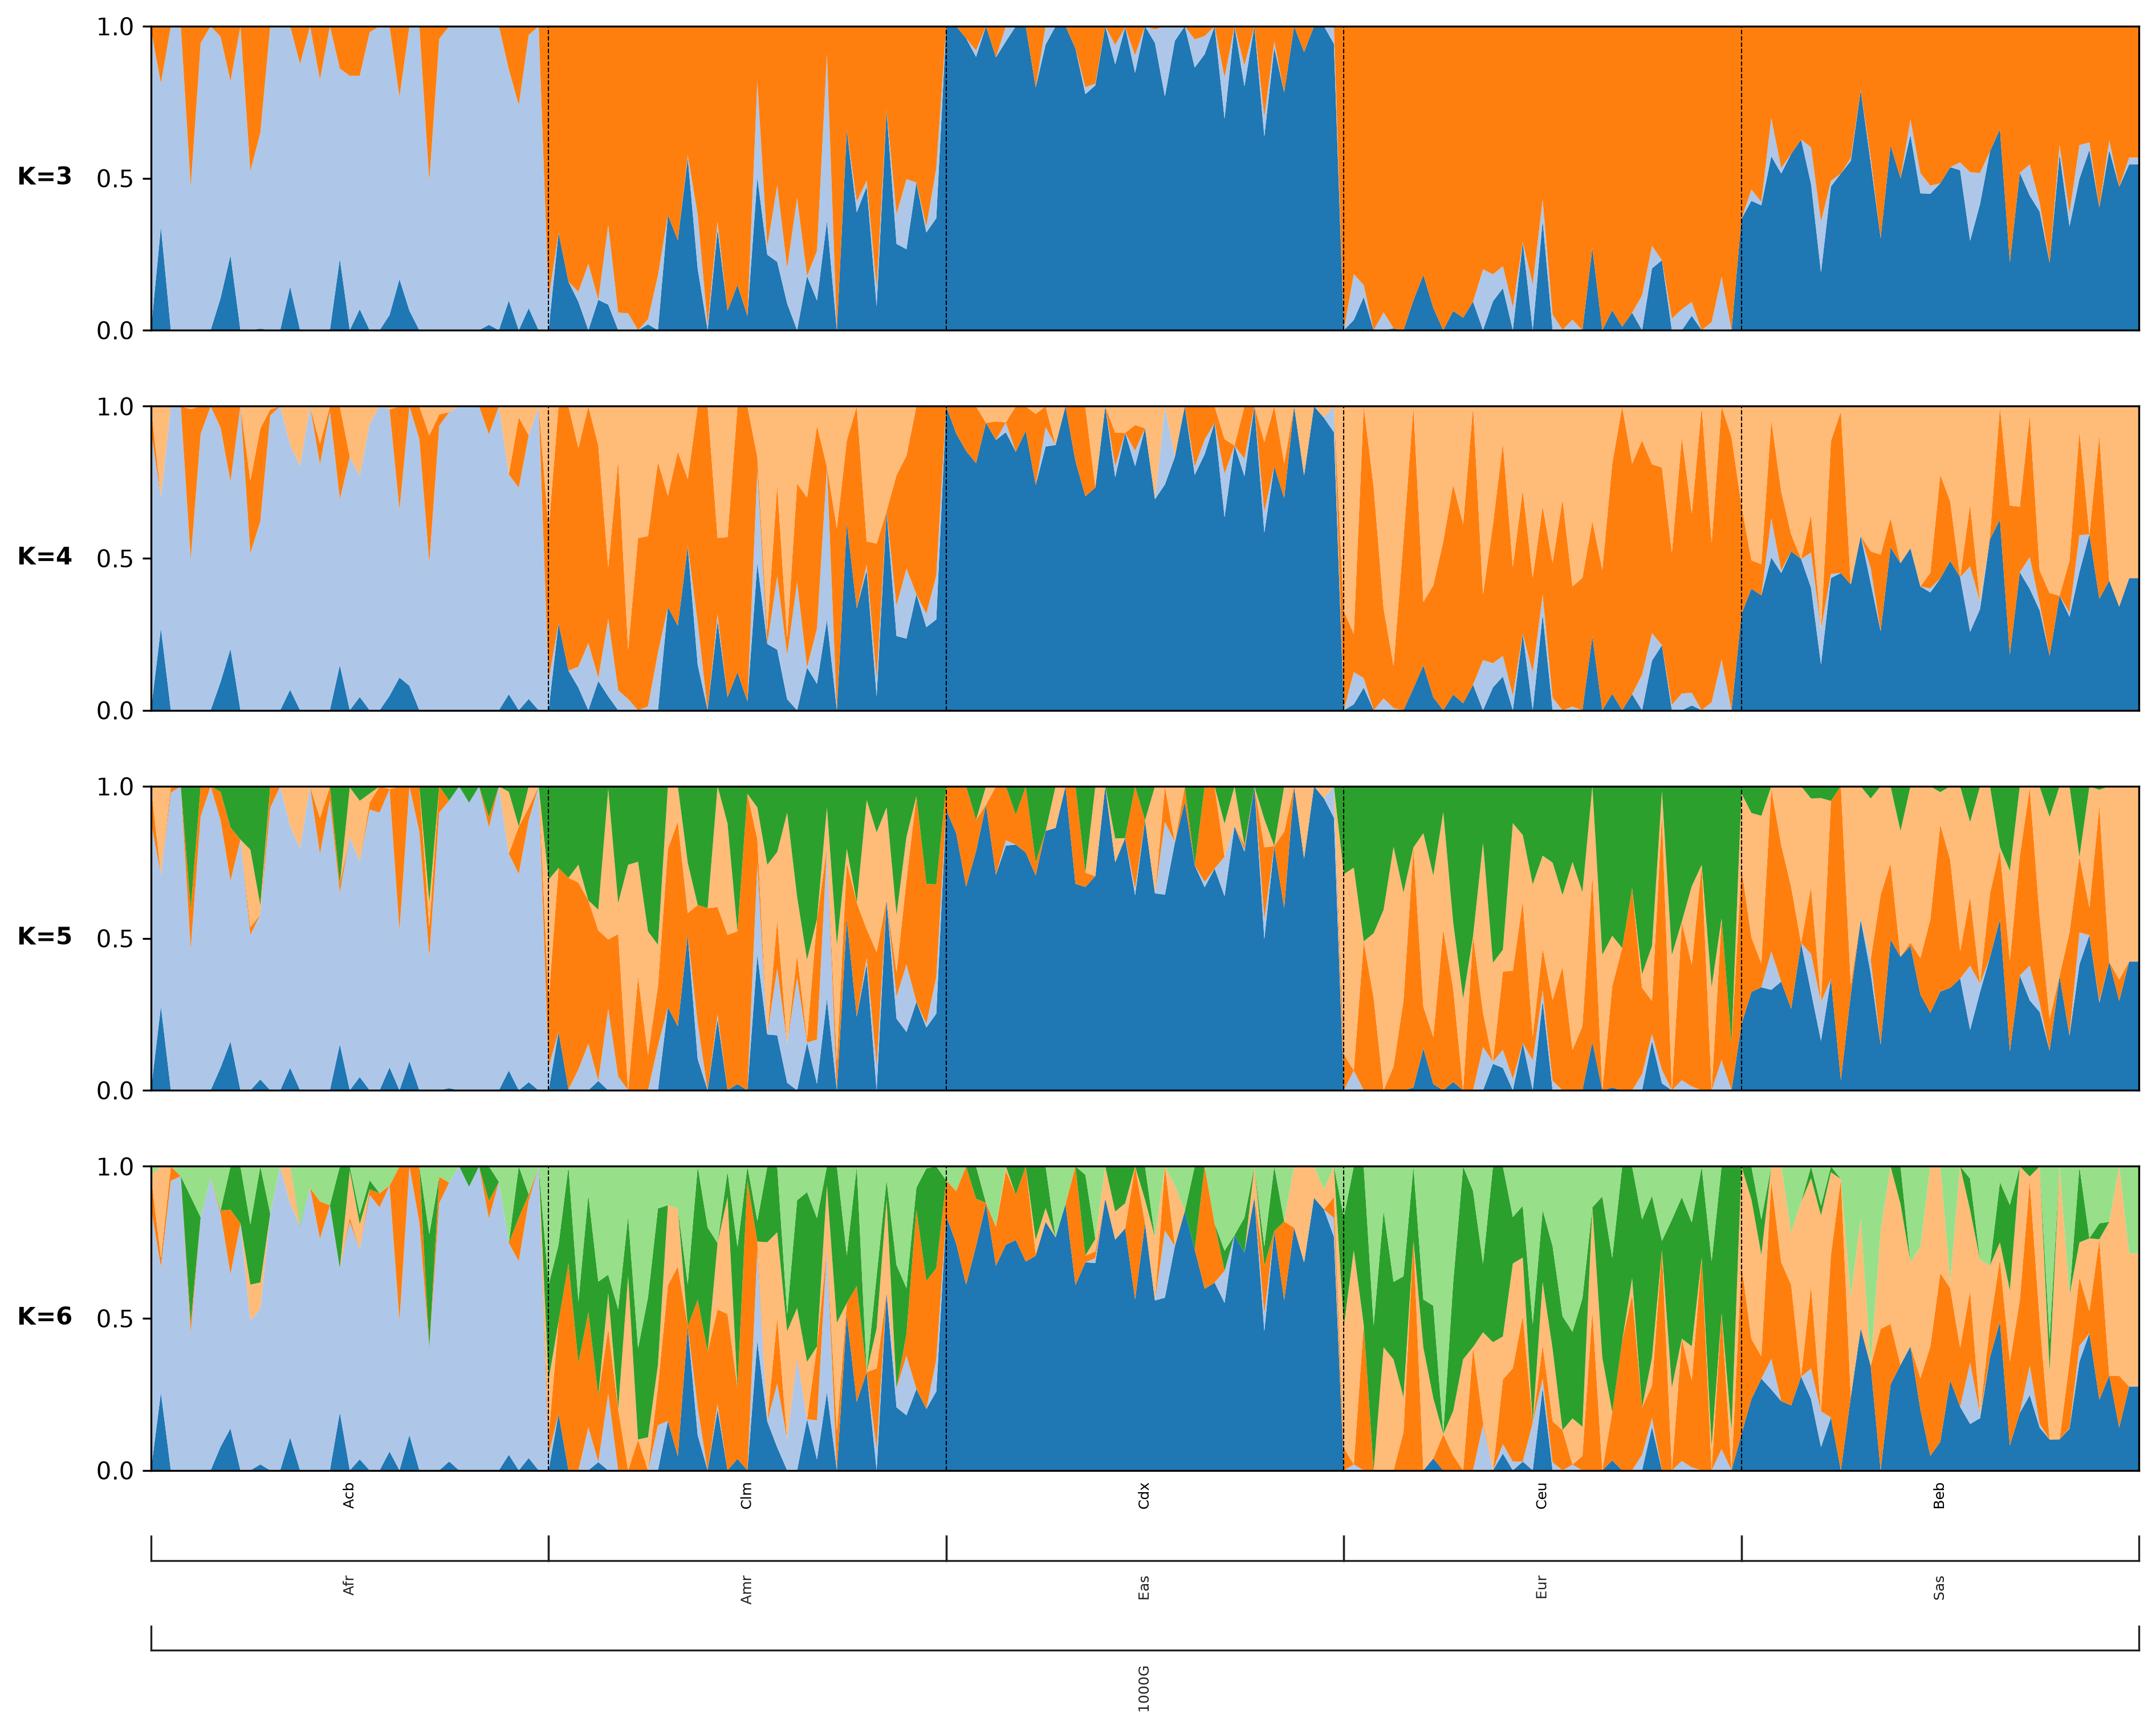

In [8]:
MULTIK_DIR = RESULTS_DIR / "unsupervised_multi_k"
MULTIK_DIR.mkdir(parents=True, exist_ok=True)

run_command([
    "adamixture",
    "--min_k", "3",
    "--max_k", "6",
    "--data_path", ALL_PGEN,
    "--save_dir", MULTIK_DIR,
    "--name", "unsupervised_multi_k",
    "--device", DEVICE,
    "--labels", ALL_POPULATION_LABELS,
    "--labels2", ALL_SUPERPOP_LABELS,
    "--labels3", ALL_GROUP_LABELS,
])

show_png(MULTIK_DIR / "unsupervised_multi_k.3_6.png")


## 8. Unsupervised Cross-Validation

This run repeats the K sweep with genotype-entry cross-validation enabled. The CV summary printed by ADAMIXTURE is parsed into an elbow plot; lower CV error is better.


$ adamixture --min_k 7 --max_k 13 --cv 3 --data_path data/processed/all_5pop_chr22.pgen --save_dir results/unsupervised_cross_validation --name unsupervised_cross_validation --device cpu --labels data/processed/all_population_labels.txt --labels2 data/processed/all_superpopulation_labels.txt --labels3 data/processed/all_group_labels.txt


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Opera

,K,CV index
0,7,0.4677
1,8,0.4641
2,9,0.4630
3,10,0.4608
4,11,0.4605
5,12,0.4604
6,13,0.4637


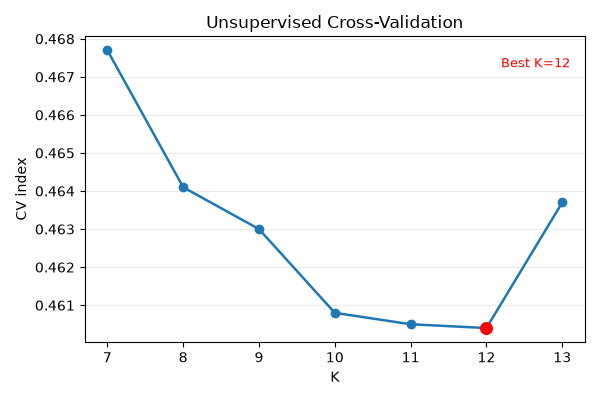

In [9]:
CV_DIR = RESULTS_DIR / "unsupervised_cross_validation"
CV_DIR.mkdir(parents=True, exist_ok=True)

cv_output = run_command([
    "adamixture",
    "--min_k", "7",
    "--max_k", "13",
    "--cv", "3",
    "--data_path", ALL_PGEN,
    "--save_dir", CV_DIR,
    "--name", "unsupervised_cross_validation",
    "--device", DEVICE,
    "--labels", ALL_POPULATION_LABELS,
    "--labels2", ALL_SUPERPOP_LABELS,
    "--labels3", ALL_GROUP_LABELS,
])

cv_matches = re.findall(r"K=(\d+): CV index = ([0-9.eE+-]+)", cv_output)
if not cv_matches:
    raise ValueError("No cross-validation summary was found in the ADAMIXTURE output.")

cv_df = pd.DataFrame({
    "K": [int(k) for k, _value in cv_matches],
    "CV index": [float(value) for _k, value in cv_matches],
})

best_row = cv_df.loc[cv_df["CV index"].idxmin()]
best_k = int(best_row["K"])
best_cv = float(best_row["CV index"])

CV_ELBOW_PLOT = CV_DIR / "unsupervised_cross_validation_elbow.png"
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cv_df["K"], cv_df["CV index"], marker="o", linewidth=1.8)
ax.scatter([best_k], [best_cv], color="red", s=70, zorder=3)
ax.text(
    0.97,
    0.93,
    f"Best K={best_k}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color="red",
    fontsize=9,
)
ax.set_xlabel("K")
ax.set_ylabel("CV index")
ax.set_title("Unsupervised Cross-Validation")
ax.set_xticks(cv_df["K"])
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(CV_ELBOW_PLOT)
plt.close(fig)

display(cv_df)
show_png(CV_ELBOW_PLOT)


## 9. Supervised Run


$ adamixture-supervised --data_path data/processed/all_5pop_chr22.pgen --save_dir results/supervised --name supervised_5pop --device cpu --labels data/processed/all_population_labels.txt --labels2 data/processed/supervised_training_labels.txt --labels3 data/processed/all_group_labels.txt --level 2


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Supervised Mode

    Input format is PGEN.
  

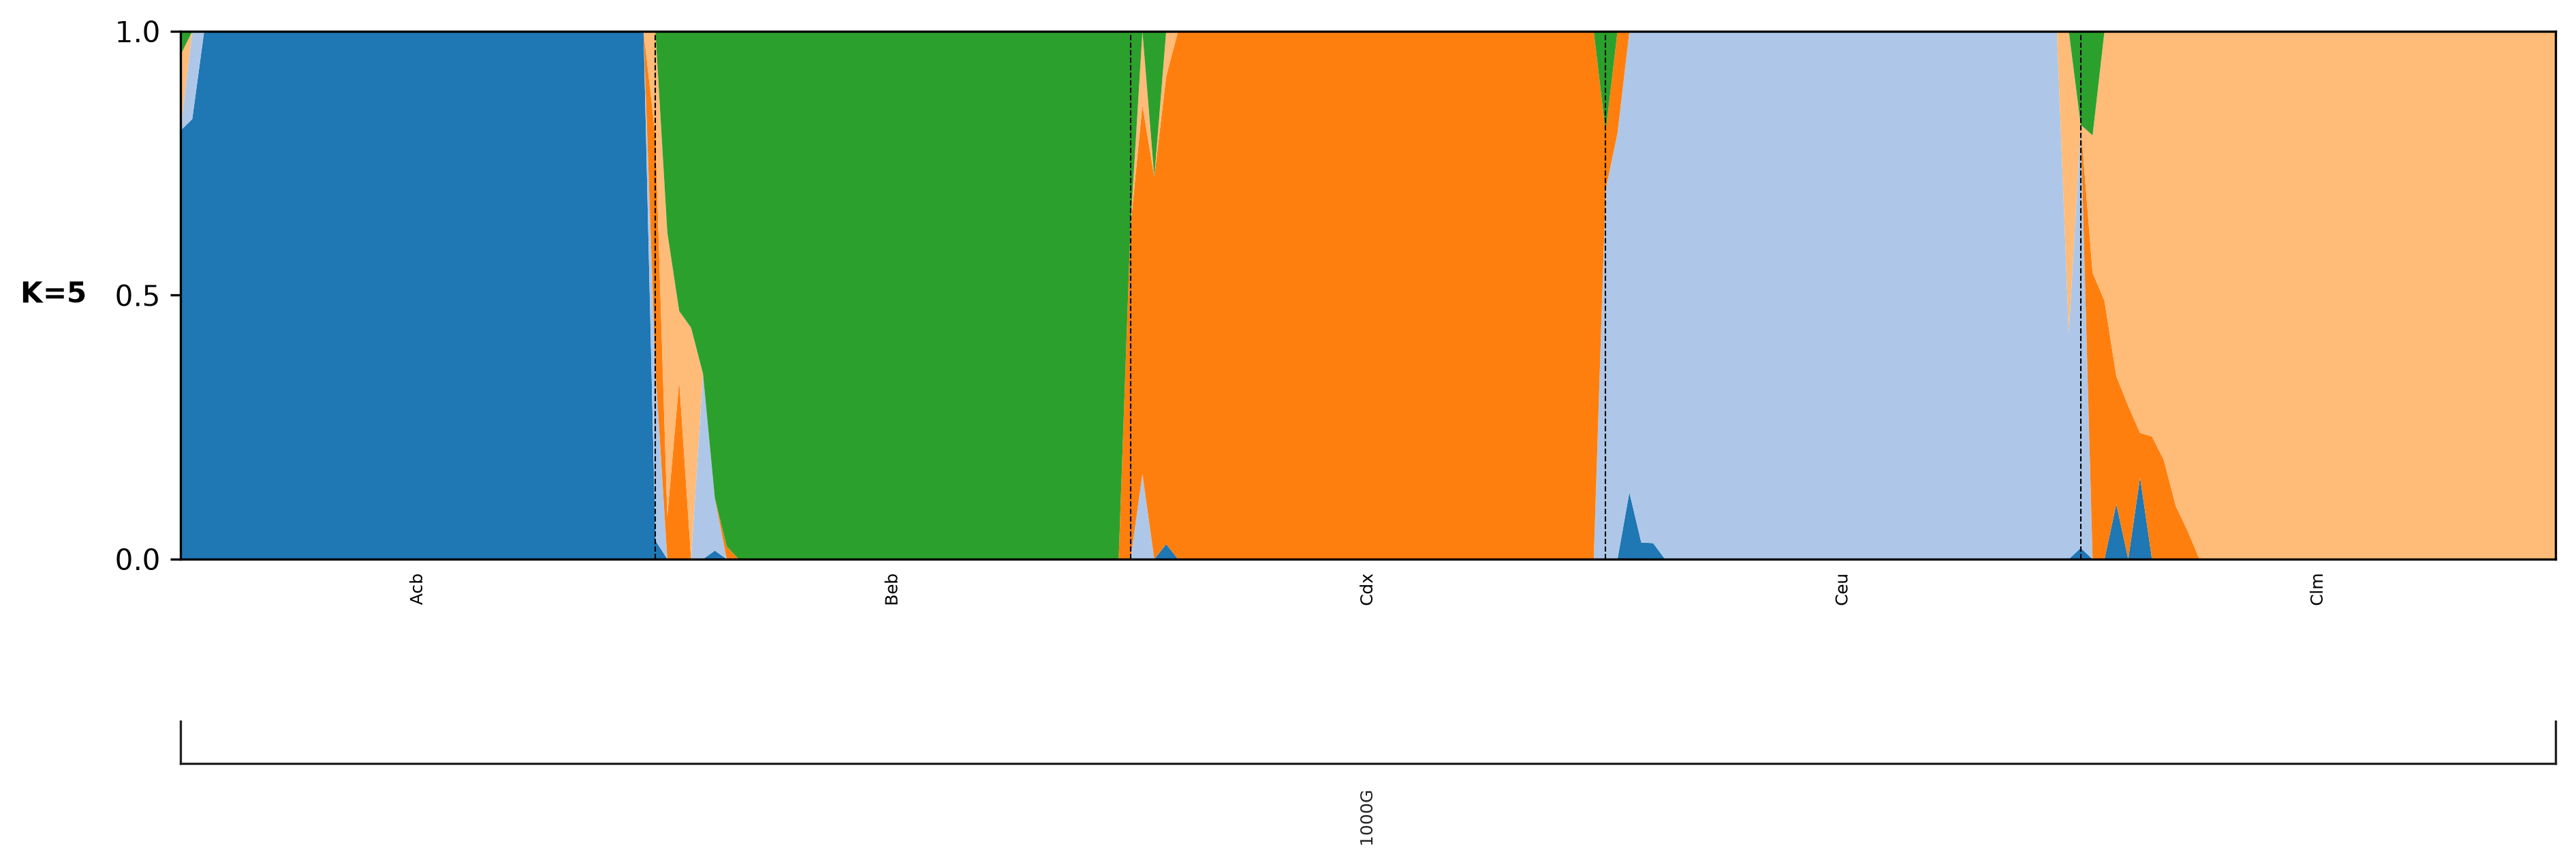

In [10]:
SUPERVISED_DIR = RESULTS_DIR / "supervised"
SUPERVISED_DIR.mkdir(parents=True, exist_ok=True)

run_command([
    "adamixture-supervised",
    "--data_path", ALL_PGEN,
    "--save_dir", SUPERVISED_DIR,
    "--name", "supervised_5pop",
    "--device", DEVICE,
    "--labels", ALL_POPULATION_LABELS,
    "--labels2", SUPERVISED_LABELS,
    "--labels3", ALL_GROUP_LABELS,
    "--level", "2",
])

show_png(SUPERVISED_DIR / "supervised_5pop.5.png")


## 10. Standalone Plotting with `adamixture-plot`


$ adamixture-plot --filemap data/processed/multi_k_filemap.tsv --labels data/processed/all_population_labels.txt --labels2 data/processed/all_superpopulation_labels.txt --labels3 data/processed/all_group_labels.txt --save_dir results/plot_only --name multi_k_posthoc_plot --format png


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Multi-run Plotting Mode

    Generating plot: multi_k_posth

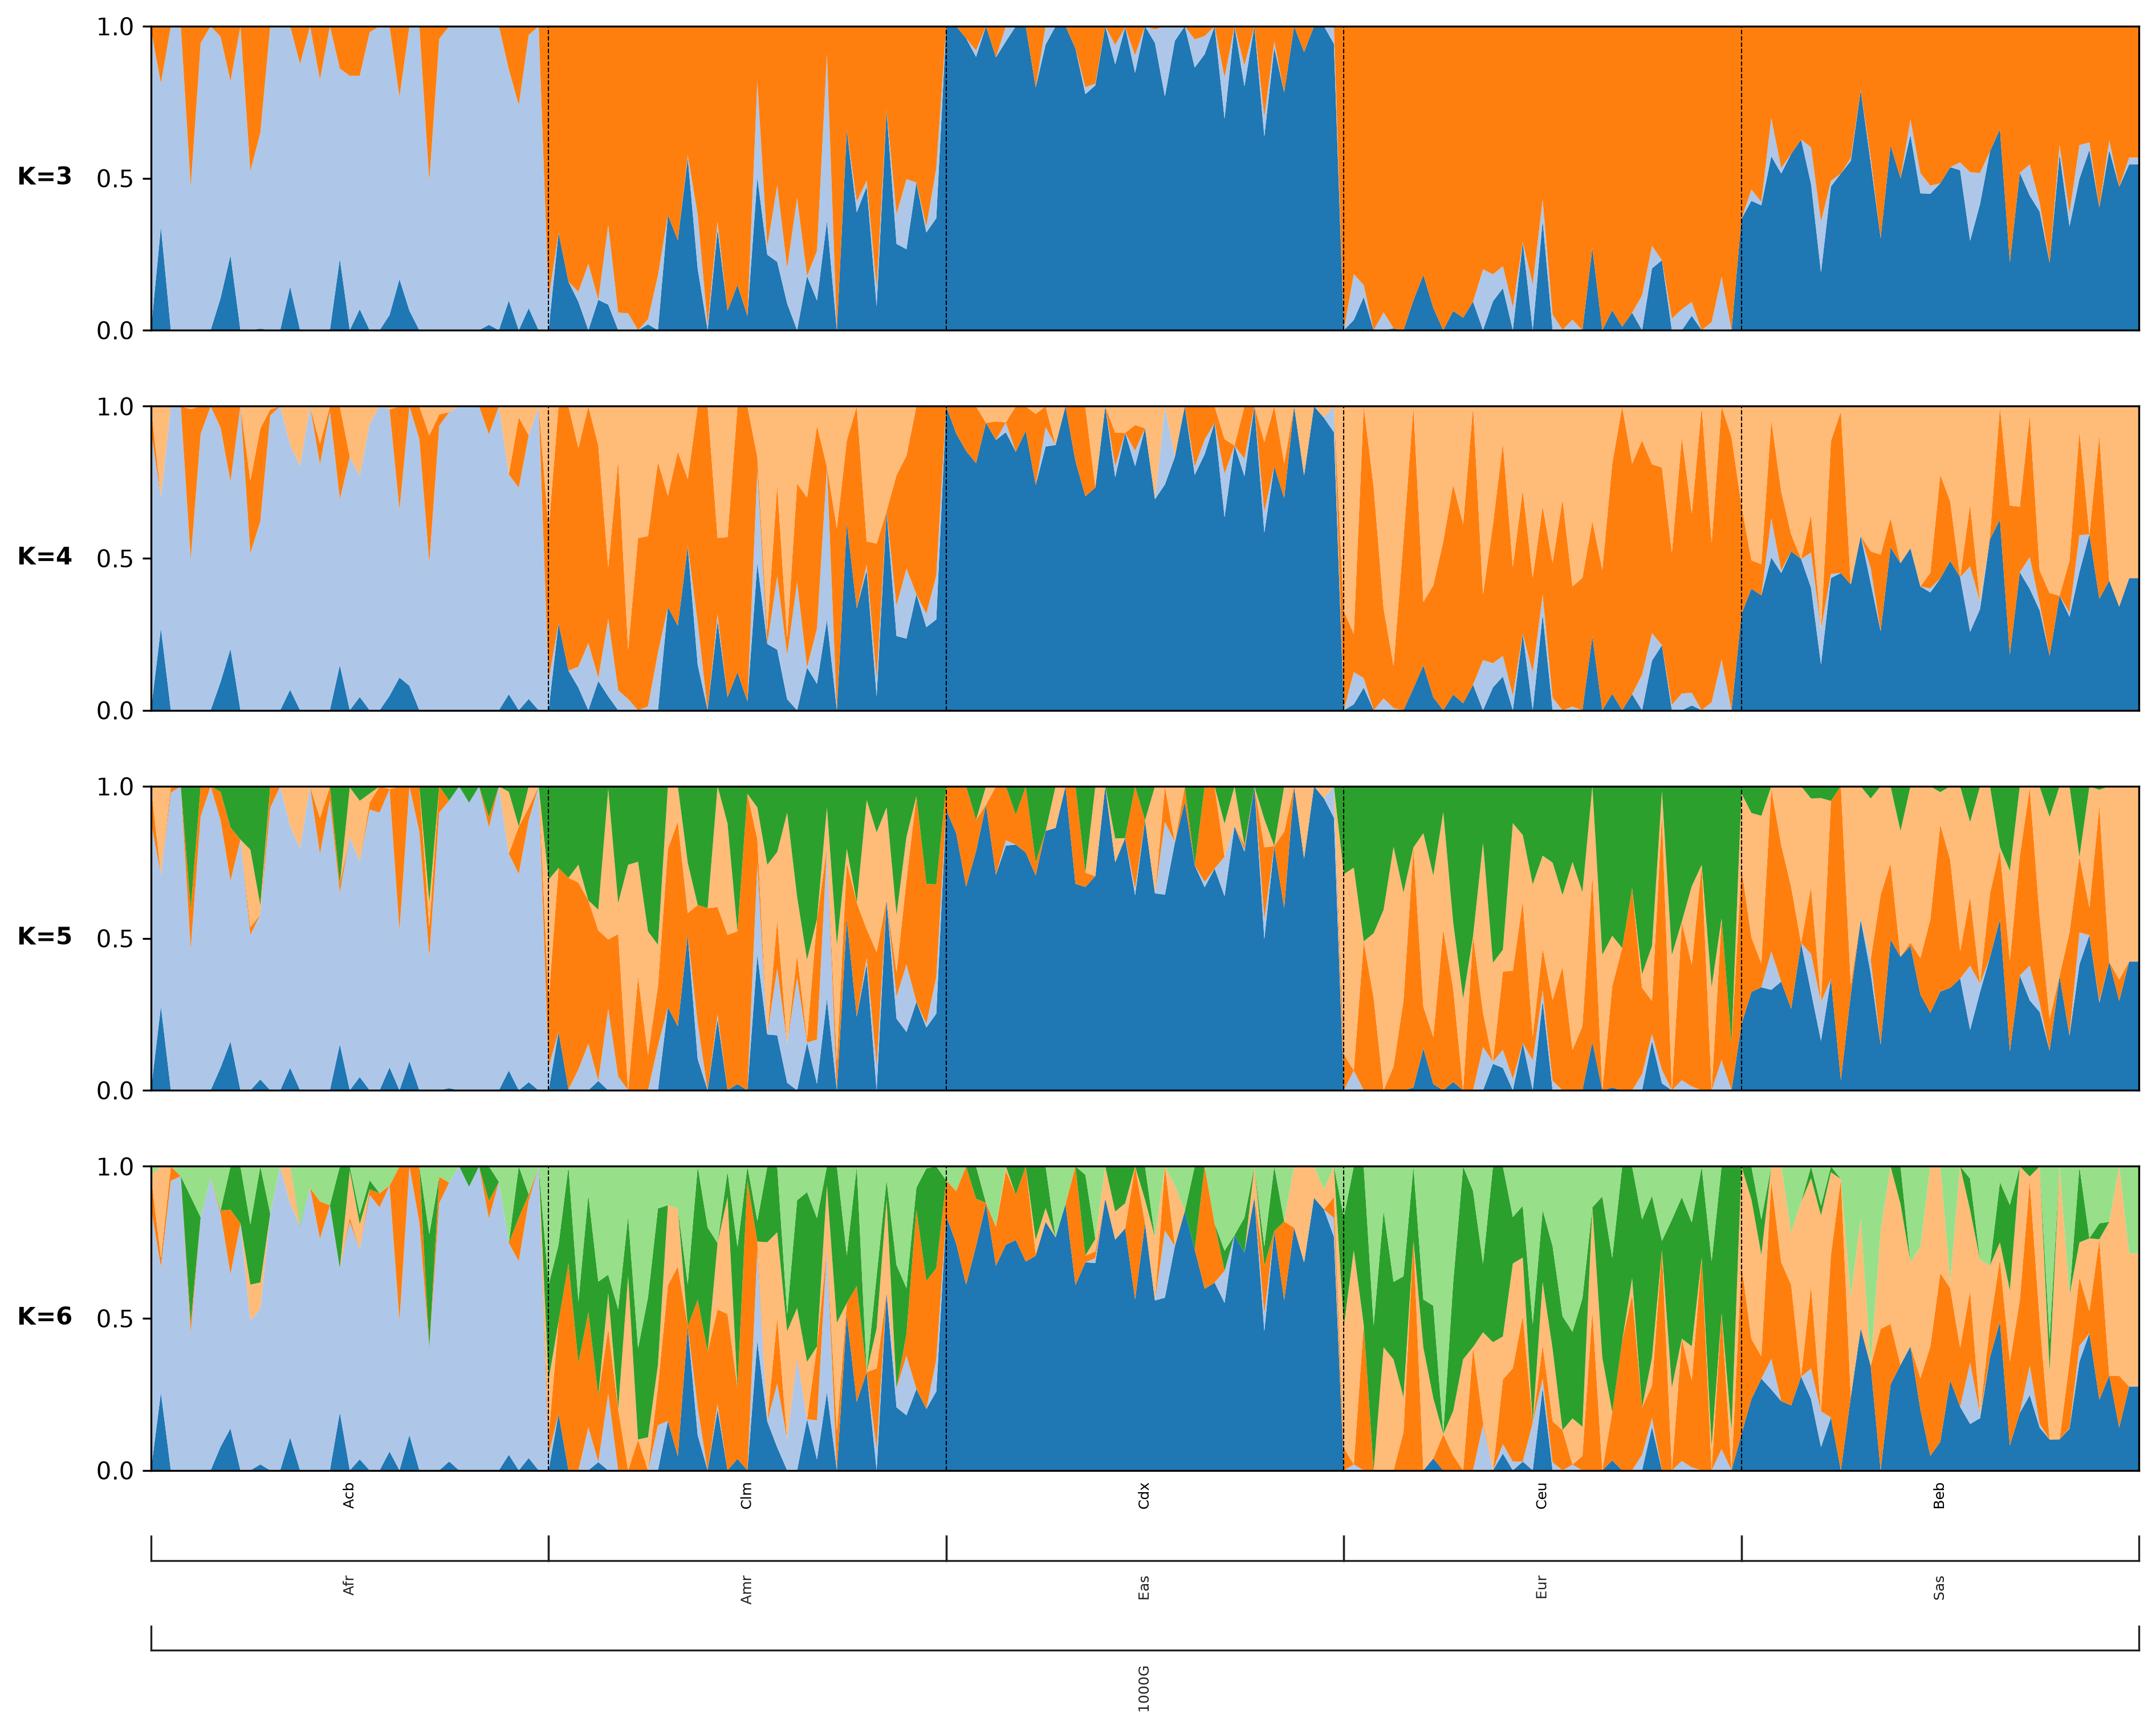

In [11]:
PLOT_DIR = RESULTS_DIR / "plot_only"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FILEMAP_PATH = PROCESSED_DIR / "multi_k_filemap.tsv"

filemap_lines = []
for k_value in [3, 4, 5, 6]:
    q_path = MULTIK_DIR / f"unsupervised_multi_k.{k_value}.Q"
    filemap_lines.append(f"MultiK{k_value}\t{k_value}\t{q_path}\n")
FILEMAP_PATH.write_text("".join(filemap_lines))

run_command([
    "adamixture-plot",
    "--filemap", FILEMAP_PATH,
    "--labels", ALL_POPULATION_LABELS,
    "--labels2", ALL_SUPERPOP_LABELS,
    "--labels3", ALL_GROUP_LABELS,
    "--save_dir", PLOT_DIR,
    "--name", "multi_k_posthoc_plot",
    "--format", "png",
])

show_png(PLOT_DIR / "multi_k_posthoc_plot.png")


## 11. Projection of Held-Out Samples

Projection requires target samples with the same variants and row order as the P matrix used for training. The PGEN preparation wrote `reference_5pop_chr22.pgen` and `target_5pop_chr22.pgen` from the same selected variant list, so they are compatible.


$ adamixture -k 5 --data_path data/processed/reference_5pop_chr22.pgen --save_dir results/projection_reference --name reference_model --device cpu --labels data/processed/reference_population_labels.txt --labels2 data/processed/reference_superpopulation_labels.txt --labels3 data/processed/reference_group_labels.txt


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898/2026.02.13.700171
    
    Operating system is Darwin 

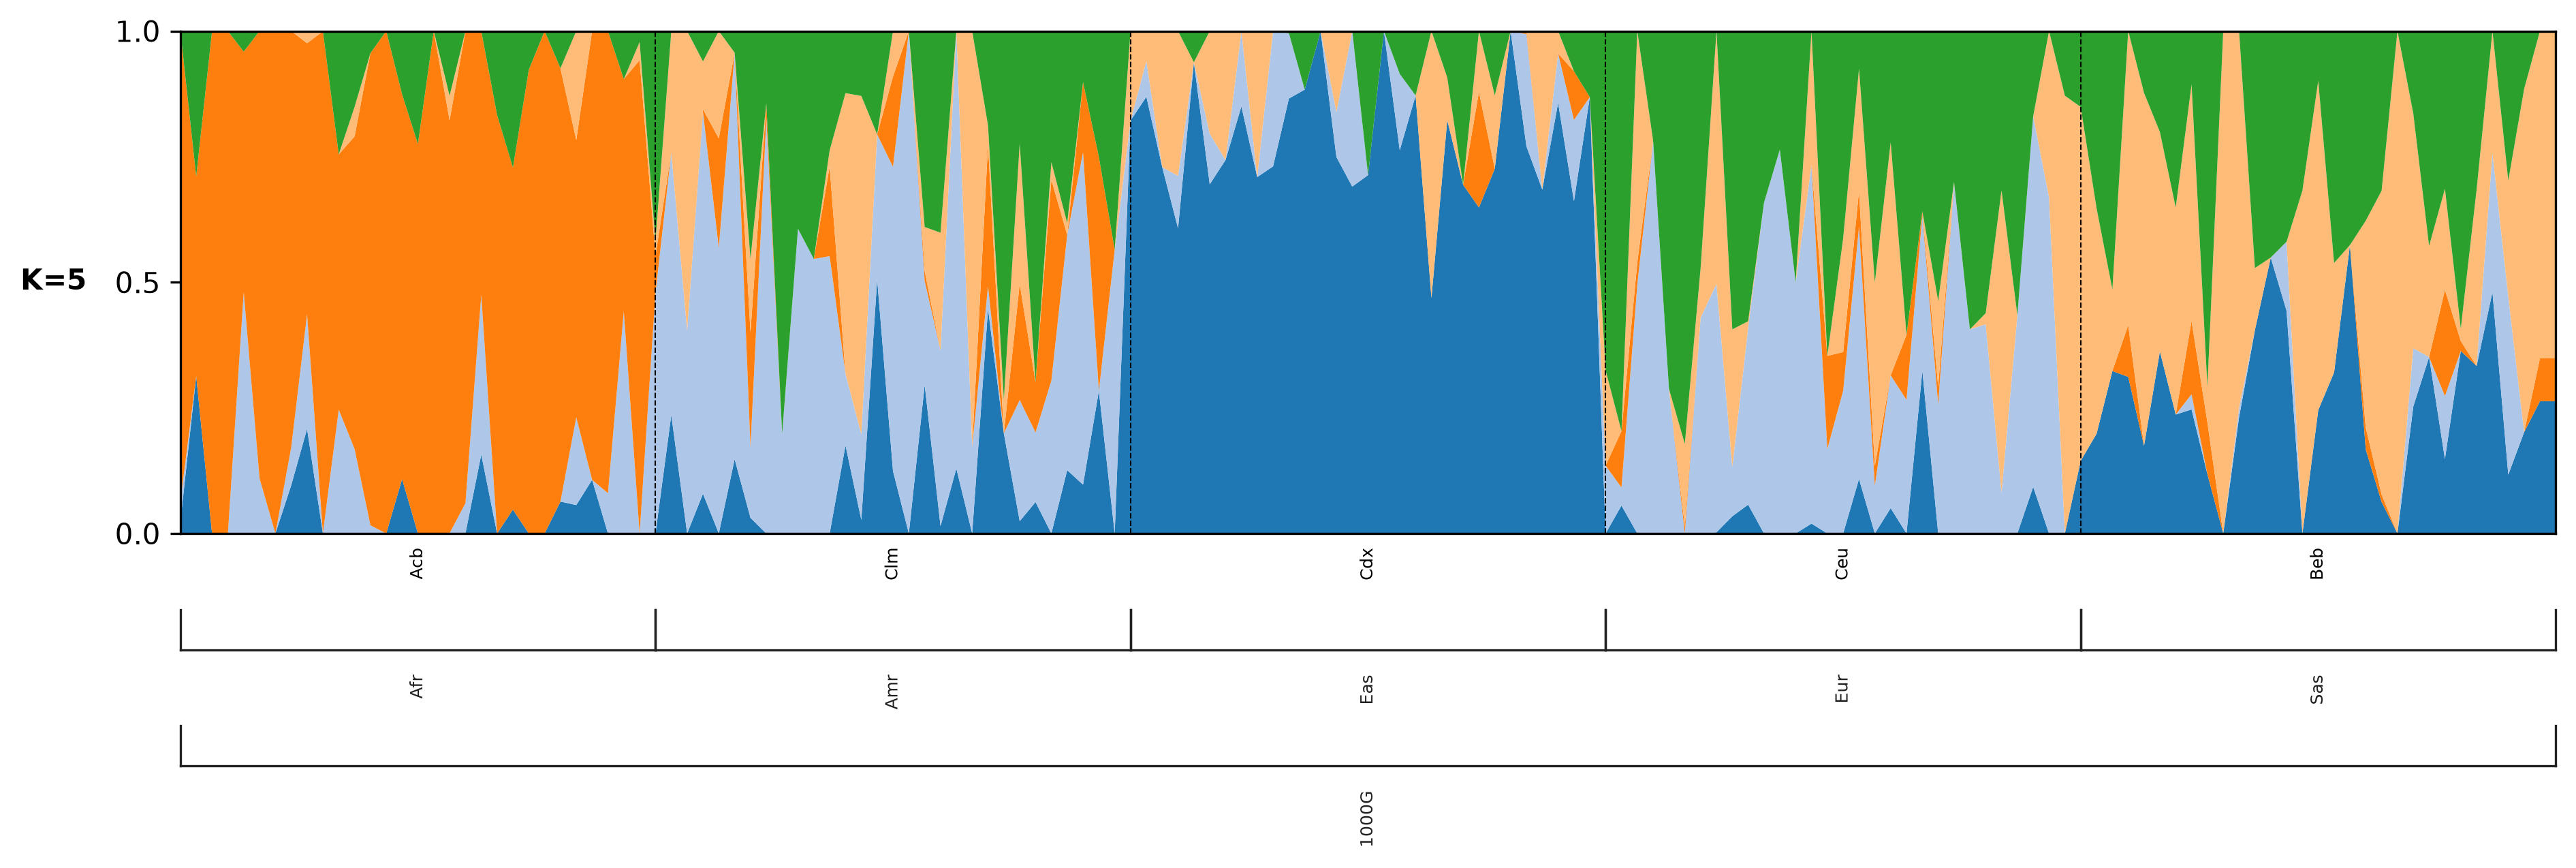

In [12]:
REFERENCE_DIR = RESULTS_DIR / "projection_reference"
PROJECTION_DIR = RESULTS_DIR / "projection_target"
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)
PROJECTION_DIR.mkdir(parents=True, exist_ok=True)

run_command([
    "adamixture",
    "-k", "5",
    "--data_path", REFERENCE_PGEN,
    "--save_dir", REFERENCE_DIR,
    "--name", "reference_model",
    "--device", DEVICE,
    "--labels", REFERENCE_POPULATION_LABELS,
    "--labels2", REFERENCE_SUPERPOP_LABELS,
    "--labels3", REFERENCE_GROUP_LABELS,
])

show_png(REFERENCE_DIR / "reference_model.5.png")


$ adamixture-project --data_path data/processed/target_5pop_chr22.pgen --p_path results/projection_reference/reference_model.5.P --save_dir results/projection_target --name projected_target_samples --device cpu --labels data/processed/target_population_labels.txt --labels2 data/processed/target_superpopulation_labels.txt --labels3 data/processed/target_group_labels.txt


      ___  ____   ___  __  __ _____ _   _ _______ _    _ _____  ______
     / _ \|  _ \ / _ \|  \/  |_   _\ \ / /__   __| |  | |  __ \|  ____|
    / /_\ | | | / /_\ | \  / | | |  \ V /   | |  | |  | | |__) | |__
    |  _  | | | |  _  | |\/| | | |   > <    | |  | |  | |  _  /|  __|
    | | | | |_| | | | | |  | |_| |_ / . \   | |  | |__| | | \ \| |____
    \_| |_/____/\_| |_|_|  |_|_____/_/ \_\  |_|   \____/|_|  \_\______|
    
    Version: 0.1.dev95+g67ea7b225.d20260708
    Authors: Joan Saurina-i-Ricos, Daniel Mas Montserrat and
             Alexander G. Ioannidis.
    Preprint: https://www.biorxiv.org/content/10.64898

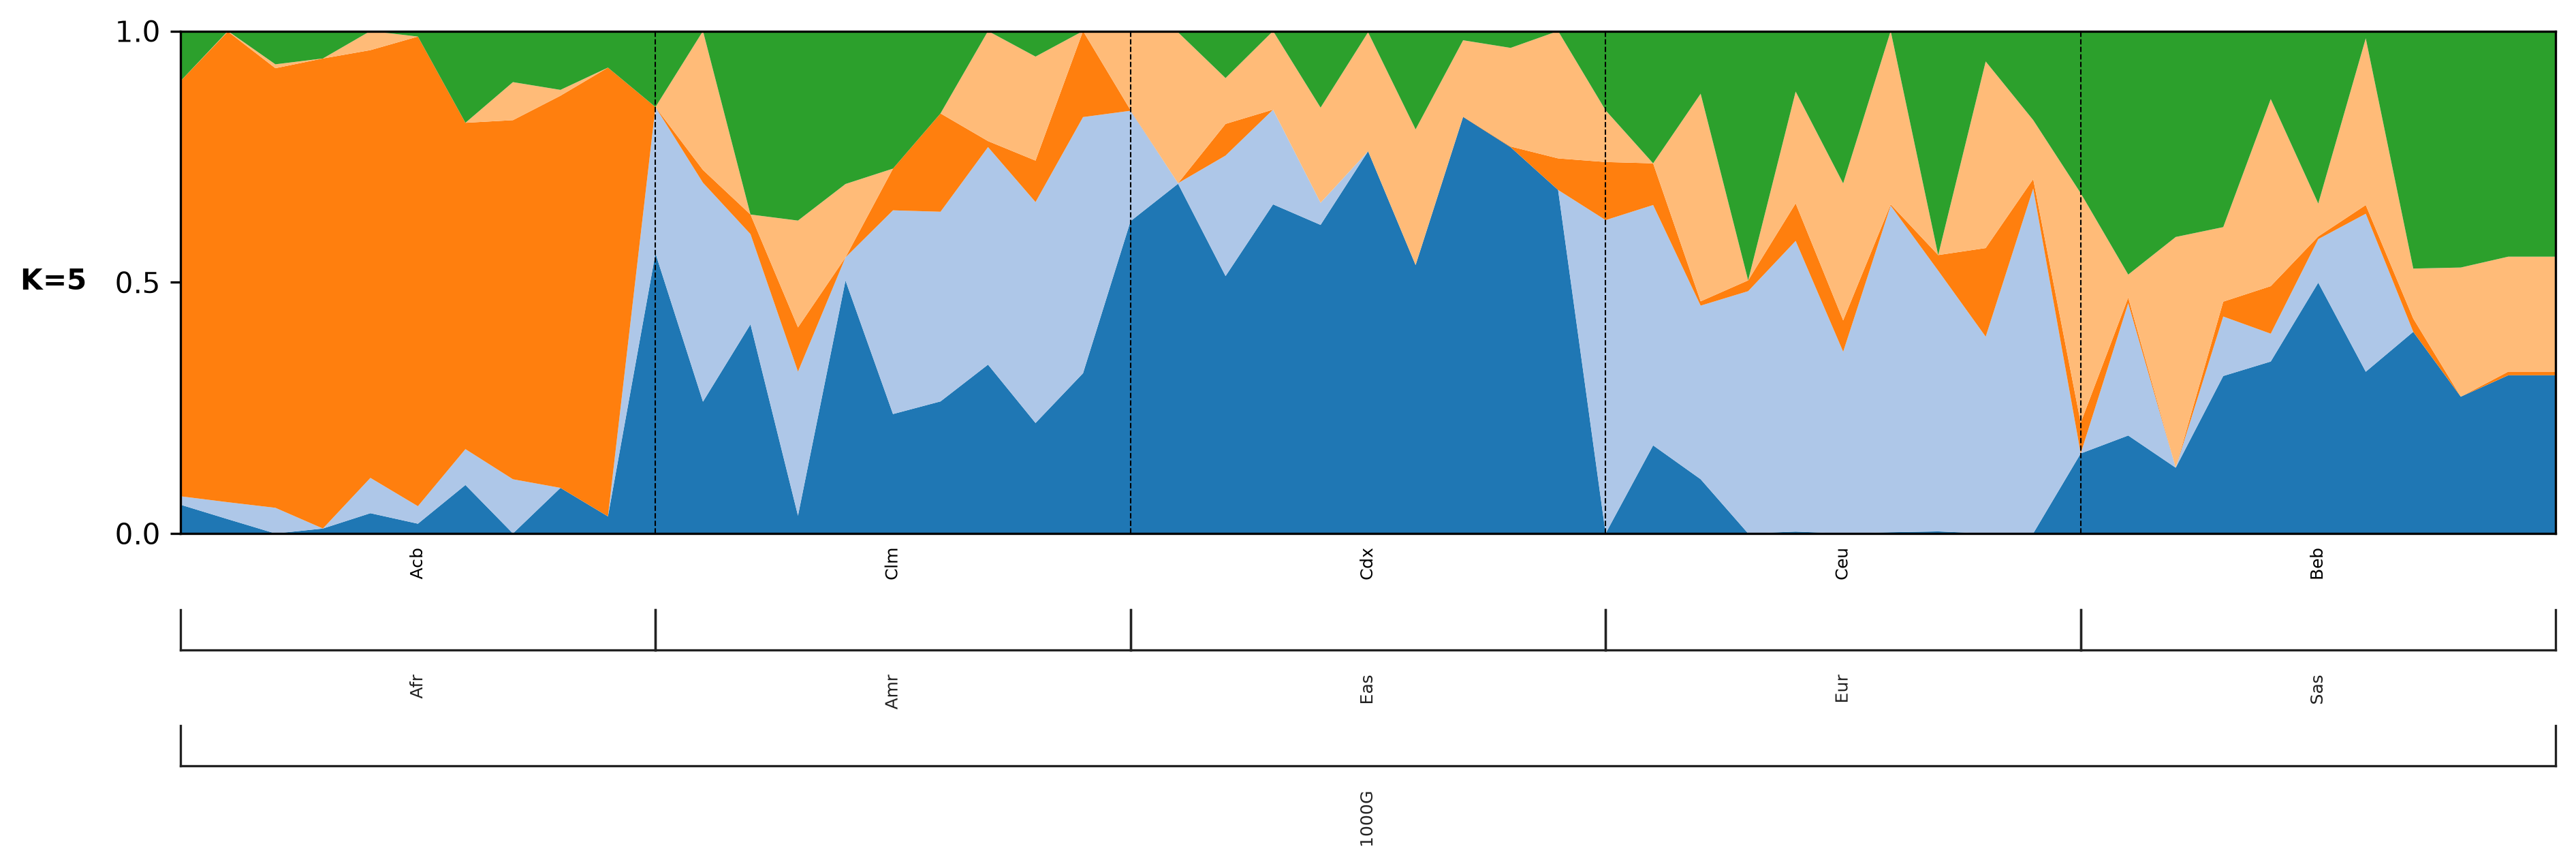

In [13]:
run_command([
    "adamixture-project",
    "--data_path", TARGET_PGEN,
    "--p_path", REFERENCE_DIR / "reference_model.5.P",
    "--save_dir", PROJECTION_DIR,
    "--name", "projected_target_samples",
    "--device", DEVICE,
    "--labels", TARGET_POPULATION_LABELS,
    "--labels2", TARGET_SUPERPOP_LABELS,
    "--labels3", TARGET_GROUP_LABELS,
])

show_png(PROJECTION_DIR / "projected_target_samples.5.png")


## 12. Output Files

The main outputs are under `.tmp/adamixture_1000_genomes_tutorial/results/`:

- `unsupervised_labeled/`: one K=5 unsupervised run and plot.
- `unsupervised_multi_k/`: K=3..6 sweep and combined plot.
- `unsupervised_cross_validation/`: K sweep with 3-fold CV and elbow plot.
- `supervised/`: supervised run and plot.
- `plot_only/`: standalone post-processing plot.
- `projection_reference/`: reference model used for projection.
- `projection_target/`: projected held-out samples and plot.
